## Content

- Problem statement intro: E-commerce

-  Intuition

- Hierarchical Clustering
    - Agglomerative Clustering
    - Divisive Clustering

- Agglomerative Clustering  
    - Dendogram
    - Types of distances
    - Proximity Matrix
    - sklearn implementation

- Evaluation
  - Quantivative : Silhouette
  - Qualitative : PCA and TSNE

- Comparision with K- means++

- Limitations of Agglomerative Clustering  

##Problem statement:



As a data scientist at **Amazon**, you are given a dataset that has details about different customers with features like
- 'ID',
- 'n_clicks',
- 'n_visits', etc,

You are asked to segment these customers so that the **Amazon** can provide relevant and similar items to their customers, which will increase their overall sale.

In [ ]:
!wget "https://drive.google.com/uc?export=download&id=1lEccW5Y5_2z00VRtLGOAJOAU6YA9fl6W" -O E-commerce.csv

--2024-04-02 08:25:01--  https://drive.google.com/uc?export=download&id=1lEccW5Y5_2z00VRtLGOAJOAU6YA9fl6W
Resolving drive.google.com (drive.google.com)... 108.177.121.113, 108.177.121.101, 108.177.121.100, ...
Connecting to drive.google.com (drive.google.com)|108.177.121.113|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1lEccW5Y5_2z00VRtLGOAJOAU6YA9fl6W&export=download [following]
--2024-04-02 08:25:01--  https://drive.usercontent.google.com/download?id=1lEccW5Y5_2z00VRtLGOAJOAU6YA9fl6W&export=download
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 142.250.128.132, 2607:f8b0:4001:c32::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|142.250.128.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 139827 (137K) [application/octet-stream]
Saving to: ‘E-commerce.csv’

E-commerce.csv      100%[===================>] 136.55K  --.

In [ ]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('./E-commerce.csv')
df.head()

,ID,n_clicks,n_visits,amount_spent,amount_discount,days_since_registration,profile_information
0,1476,130,65,213.905831,31.600751,233,235
1,1535,543,46,639.223004,5.689175,228,170
2,1807,520,102,1157.402763,844.321606,247,409
3,1727,702,83,1195.903634,850.041757,148,200
4,1324,221,84,180.754616,64.283300,243,259


In [ ]:
df.shape

(2500, 7)

In [ ]:
df.set_index('ID',inplace=True)

In [ ]:
df.head()

,n_clicks,n_visits,amount_spent,amount_discount,days_since_registration,profile_information
ID,,,,,,
1476,130,65,213.905831,31.600751,233,235
1535,543,46,639.223004,5.689175,228,170
1807,520,102,1157.402763,844.321606,247,409
1727,702,83,1195.903634,850.041757,148,200
1324,221,84,180.754616,64.283300,243,259


In [ ]:
df.index.name = None

In [ ]:
df.head()

,n_clicks,n_visits,amount_spent,amount_discount,days_since_registration,profile_information
1476,130,65,213.905831,31.600751,233,235
1535,543,46,639.223004,5.689175,228,170
1807,520,102,1157.402763,844.321606,247,409
1727,702,83,1195.903634,850.041757,148,200
1324,221,84,180.754616,64.283300,243,259


Let's see what all do we have for the given problem statement:

- First thing to note is that there are no labels for the records in the dataset.

- What this means? We cannot use Supervised Learning methods to solve our problem, and we would have to use Unsupervised methods.


Recall the introductory class of machine learning where we saw that there is a type of unsupervised learning technique called clustering.

**Q. Do you think clustering can be used here?**

- Yes, here we are asked to group customers together who are similar.

## **Hierarchical Clustering**
---

There are two ways of performing Hierarchical Clustering
  
  1. Agglomerative (Popular and Widely used)
  2. Divisive

#### **Intuition of Agglomerative Clustering**

**How does it work ?**
- 1 Iteration : Initiazing all n data points as cluster.
  - Since we 5 data points that means we have 5 clusters.


<img src="https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/069/355/original/1.png?1711628761" width = 600>

- 2 Iteration : Merge the nearset cluster
  -  Now after merging we have 4 cluster

<img src="https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/069/357/original/2.png?1711629661
" width = 600>

- 3 Interation : Again merging the nearset clusters and now we have 3 three clusters


<img src="https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/069/702/original/3.png?1711952767
" width = 600>

**Note** : At each interation we merge the nearby clusters until one cluster is left.

#### Agglomerative Clustering



- The word agglomerative suggests combining things.
- Agglomerative clustering starts with the assumption that every datapoint is a cluster, so  intially if there are 10 datapoints i.e we have 10 clusters.
- Then, in each iteration we merge nearby two clusters until  there is only a single cluster left


<img src="https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/069/108/original/clustering.gif?1711525682" width =600>


### Dendrogram
---




- Since Agglomerative clustering is also called bottom-up approach, we would understand the concept of dendrogram.
- The height in the dendrogram is the distance between the merging clusters.
- Observe the clustering happening on the left with dendrogram forming on the right.

In [ ]:
from IPython.display import Image
Image(url='https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/015/038/original/hierarch.gif?1663699414')

## Proximity Matrix
---



- Proximity matrix  will tell us the distance between each of these points
- The diagnol will be zero in this matix.
- Since we are calculating the distance of each point from each of the other points, we will get a square matrix of shape n X n (where n is the number of observations).
- Let’s make the 5 x 5 proximity matrix for our example:



<img src="https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/069/276/original/cluster.png?1711606863" width=500>

- After each itertaion proximity matrix get's updated. **And how do we do it ?**
-  Let's suppose these are 5 individual cluster.

<img src="https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/069/279/original/clusters.png?1711608465" width=500>

- We will look at the smallest distance in the proximity matrix and merge the points with the smallest distance. We then update the proximity matrix:

<img src="https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/069/280/original/matrix.png?1711608563" width=400>

- Here, the smallest distance is 3 and hence we will merge point 1 and 2
- Rows and column of 1 and 2 cluster will be removed and new cluster (1,2) will be made.
- Let’s look at the updated clusters and accordingly update the proximity matrix:

<img src="https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/069/281/original/updated_cluster.png?1711608875" width=400>

-  Now, we will again calculate the proximity matrix for these clusters since we have a new merged cluster

-  We will repeat step  until only a single cluster is left.




### How do I know how many cluster do I need ?

- If we notice we get all cluster in agglomerative clustering.
- The no of cluster required depends on desired need of the business case/domain knowledge

### Using denodrogram to find the no of cluster



- Depemding on where do you horizontally cut the dendrogram you can get the desired no of cluster.
- If you cut at a upper level you will less cluster as shown in the image. As the red dotted line is giving us 4 cluster.
- If you cut the dendrogram at lower level the no of cluster will increase.


<img src="https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/069/294/original/dendro.png?1711616546" width=600>

## Measurement of distance between clusters
---





**How do you deteremine the distance between the clusters ?**
- While updating proximity matrix we calculated the distance between cluster but how ?

#### 1. Average Linkage


- Using centre of the clusters to measure the distance between them.


<img src="https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/069/717/original/4.png?1711960025" width=600>

#### 2. Single linkage

- Using the nearest points between the clusters to measure the distance


<img src="https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/069/719/original/5.png?1711960638" width=600>

#### 3. Complete linkage

- Taking the furthest points between the two cluster.


<img src="https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/069/721/original/6.png?1711960761" width=600>

#### 4. Ward Linkage

- Ward linkage calculates the variance (or equivalently, the sum of squared differences) within each individual cluster.
- In the image given below we calcuated WCSS_A and WCSS_B.
- Before we merge clusters A and B, Ward linkage looks at the increase in the total within-cluster he sum of squared differences that would result from merging them.
- The decision to merge is based on minimizing the overall increase in within-cluster sum of squared differences. In other words, Ward linkage aims to create clusters that are compact and well-separated by minimizing the spread of data points within clusters.

<img src="https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/069/730/original/7.png?1711961808" width=600>

## Hierarchical Clustering Implementation



So, we saw how powerful Hierarchical clustering is.

Let's now use this for solving our use case, that is, how can we enhance our portfolio allocation by leveraging some Data Science techniques!!!


#### Performing Agglomerative Clustering


In [ ]:
  import pandas as pd
  import numpy as np
  from matplotlib import pyplot as plt
  plt.rcParams["figure.figsize"] = (18,10)
  import seaborn as sns

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaler.fit(df)
X=scaler.transform(df)

In [ ]:
X

array([[0.06688963, 0.22088353, 0.03257084, 0.01301296, 0.45330739,
        0.4017094 ],
       [0.41220736, 0.14457831, 0.0973327 , 0.00234276, 0.44357977,
        0.29059829],
       [0.39297659, 0.36947791, 0.17623449, 0.34768545, 0.48054475,
        0.6991453 ],
       ...,
       [0.27173913, 0.40562249, 0.        , 0.        , 0.16342412,
        0.77606838],
       [0.18478261, 0.08835341, 0.48580837, 0.03217462, 0.21595331,
        0.36752137],
       [0.63879599, 0.45381526, 0.21235018, 0.43873046, 0.48249027,
        0.25470085]])

In [ ]:
scaled_df = pd.DataFrame(X, columns=df.columns, index=df.index)

In [ ]:
scaled_df

,n_clicks,n_visits,amount_spent,amount_discount,days_since_registration,profile_information
1476,0.066890,0.220884,0.032571,0.013013,0.453307,0.401709
1535,0.412207,0.144578,0.097333,0.002343,0.443580,0.290598
1807,0.392977,0.369478,0.176234,0.347685,0.480545,0.699145
1727,0.545151,0.293173,0.182097,0.350041,0.287938,0.341880
1324,0.142977,0.297189,0.027523,0.026471,0.472763,0.442735
...,...,...,...,...,...,...
1854,0.630435,0.441767,0.076536,0.153769,0.706226,0.182906
1190,0.361204,0.200803,0.080704,0.050502,0.217899,0.605128
1316,0.271739,0.405622,0.000000,0.000000,0.163424,0.776068
32,0.184783,0.088353,0.485808,0.032175,0.215953,0.367521


In [ ]:
# import hierarchical clustering libraries
import scipy.cluster.hierarchy as sch

# Refer https://docs.scipy.org/doc/scipy/reference/generated/scipy.cluster.hierarchy.linkage.html#scipy.cluster.hierarchy.linkage
Z = sch.linkage(scaled_df, method='ward') #linkage = ward

In [ ]:
Z.shape

(2499, 4)

In [ ]:
Z

array([[1.16000000e+03, 1.17700000e+03, 2.66955703e-02, 2.00000000e+00],
       [1.49000000e+02, 4.67000000e+02, 2.75989561e-02, 2.00000000e+00],
       [2.61000000e+02, 2.05300000e+03, 3.09206445e-02, 2.00000000e+00],
       ...,
       [4.99100000e+03, 4.99500000e+03, 6.79908800e+00, 1.17600000e+03],
       [4.99300000e+03, 4.99600000e+03, 1.17124842e+01, 1.78600000e+03],
       [4.99400000e+03, 4.99700000e+03, 1.51323508e+01, 2.50000000e+03]])

- The first 2 columns are cluster name.
- 3rd column is the distance between them
- 4th column tell you no of data points inside that cluster


Text(0, 0.5, 'distance')

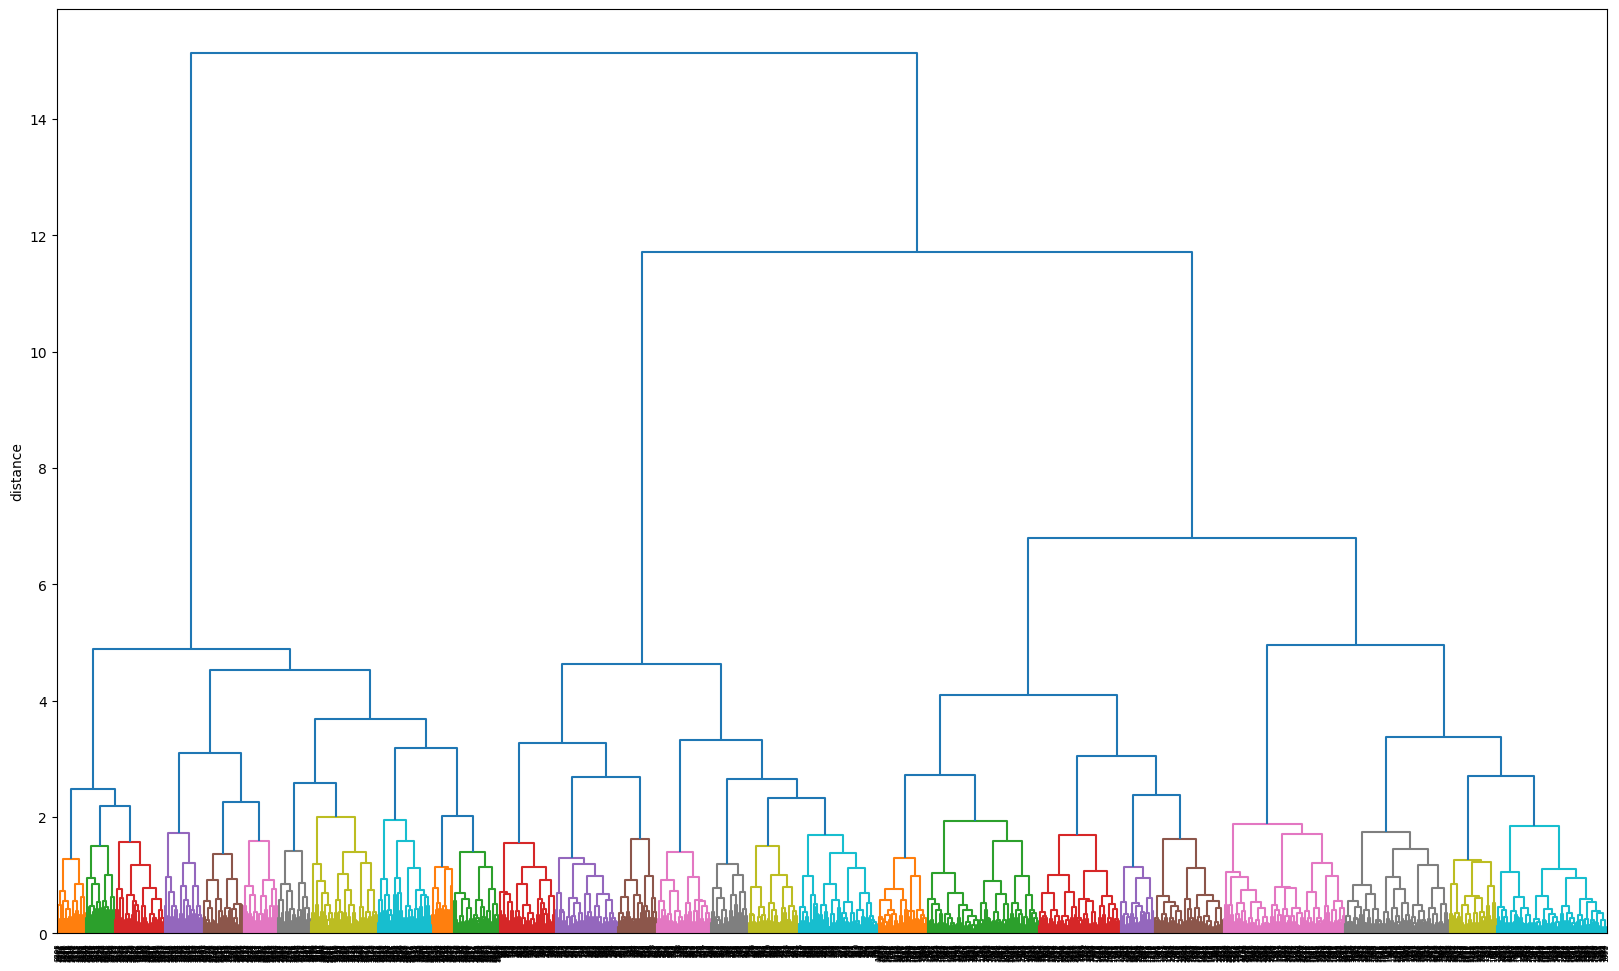

In [ ]:
fig, ax = plt.subplots(figsize=(20, 12))
sch.dendrogram(Z, labels=scaled_df.index, ax=ax, color_threshold=2)
plt.xticks(rotation=90)
ax.set_ylabel('distance')

#### **Interpreting the Dendrogram**
- Note that we are now plotting customer that are similar to one another.
- The leaves of the tree correspond to the records.
- The length of the branch in the tree indicates the degree of dissimilarity between corresponding clusters.



#### **Calculating the number of clusters**

Text(0, 0.5, 'distance')

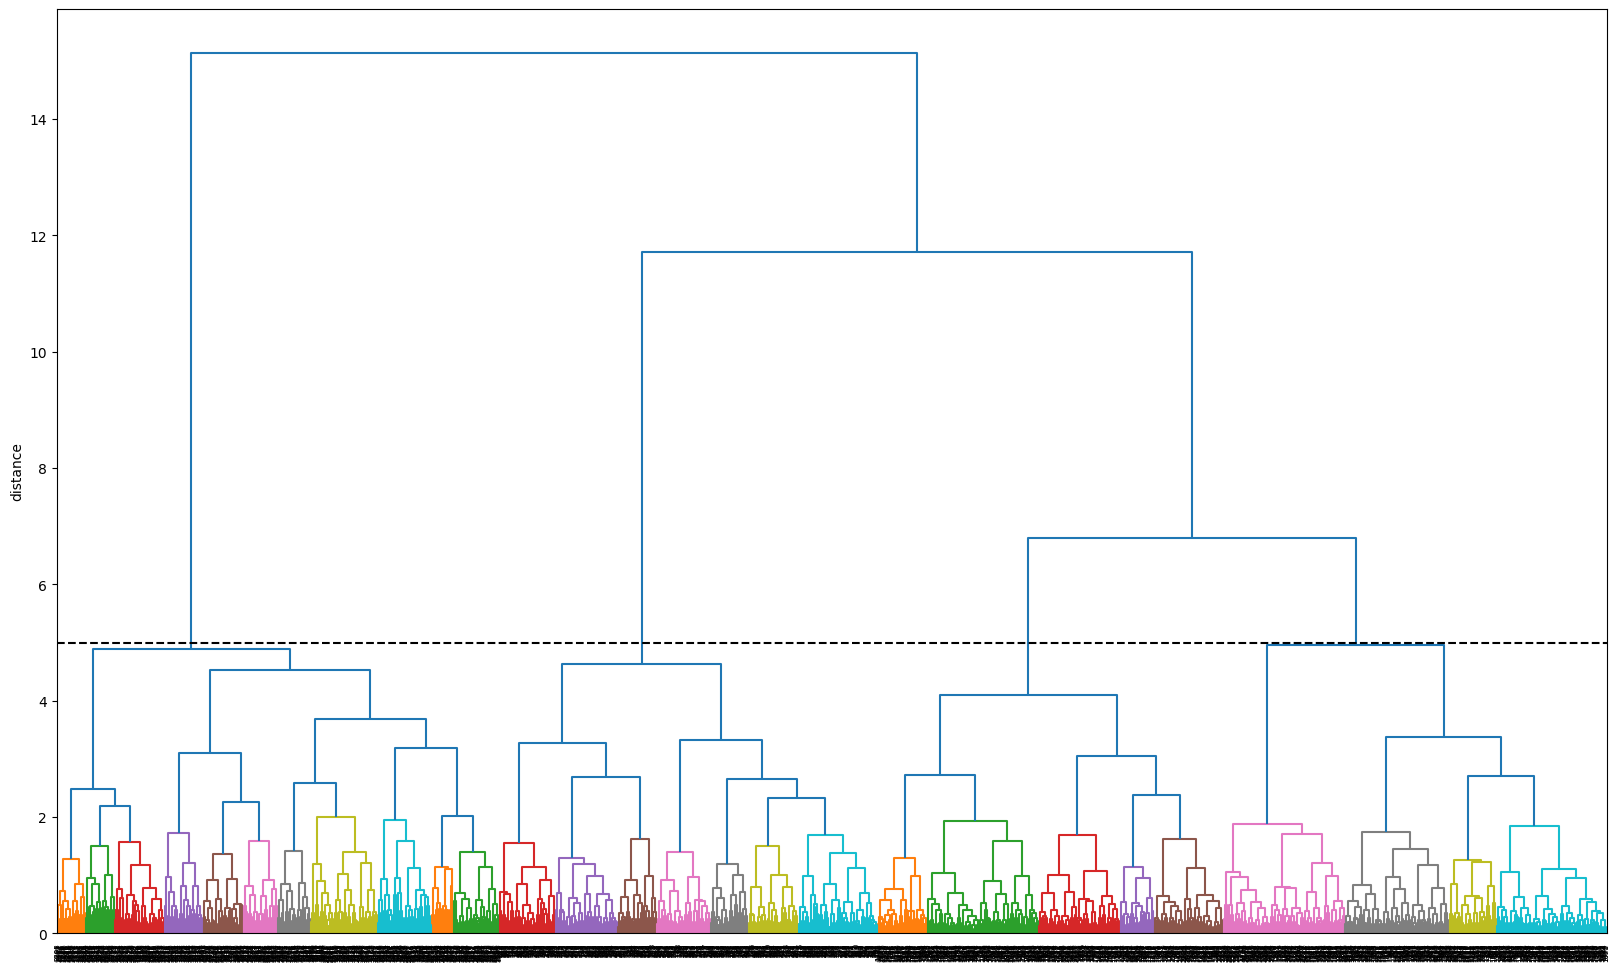

In [ ]:
fig, ax = plt.subplots(figsize=(20, 12))
sch.dendrogram(Z, labels=scaled_df.index, ax=ax, color_threshold=2)
plt.xticks(rotation=90)
plt.axhline(y=5, color='k', linestyle='--')
ax.set_ylabel('distance')

#### **Performing Agglomerative Clustering with 5 clusters**

In [ ]:
# import hierarchical clustering libraries
from sklearn.cluster import AgglomerativeClustering


# create clusters
hc_2020 = AgglomerativeClustering(n_clusters=5, affinity = 'euclidean', linkage = 'ward')
y_pred = hc_2020.fit_predict(scaled_df)

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_agglomerative.py:983: FutureWarning: Attribute `affinity` was deprecated in version 1.2 and will be removed in 1.4. Use `metric` instead
  warnings.warn(


In [ ]:
y_pred

array([1, 1, 0, ..., 1, 2, 0])

In [ ]:
viz_df = scaled_df
viz_df['Y_Predicted'] = y_pred

In [ ]:
viz_df.head()

,n_clicks,n_visits,amount_spent,amount_discount,days_since_registration,profile_information,Y_Predicted
1476,0.066890,0.220884,0.032571,0.013013,0.453307,0.401709,1
1535,0.412207,0.144578,0.097333,0.002343,0.443580,0.290598,1
1807,0.392977,0.369478,0.176234,0.347685,0.480545,0.699145,0
1727,0.545151,0.293173,0.182097,0.350041,0.287938,0.341880,0
1324,0.142977,0.297189,0.027523,0.026471,0.472763,0.442735,1


##### **Plotting the characteristics of the learned clusters**

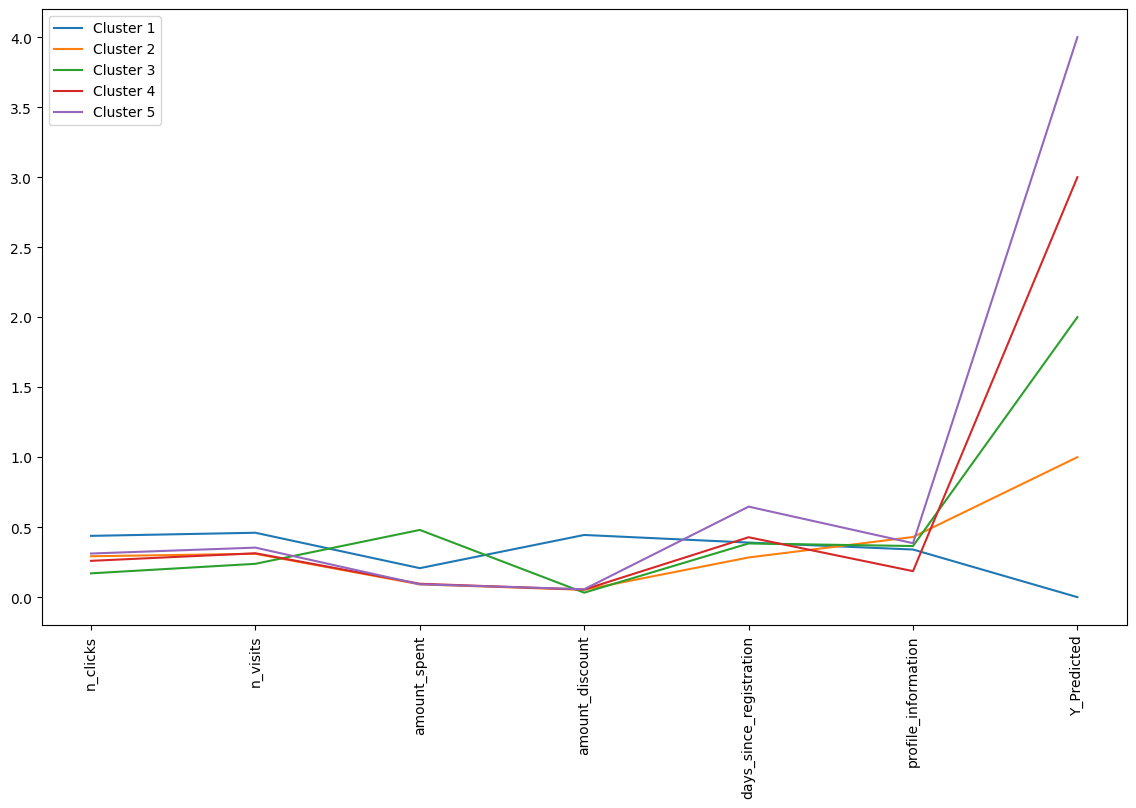

In [ ]:
#Plot a line graph to see the characteristics of the clusters
scaled_df['label'] = pd.Series(y_pred, index=scaled_df.index)

clustered_df = scaled_df.groupby('label').mean()

labels = ['Cluster 1', 'Cluster 2', 'Cluster 3', 'Cluster 4', 'Cluster 5']

plt.figure(figsize=(14,8))
plt.plot(clustered_df.T, label=labels)
plt.xticks(rotation=90)
plt.legend(labels)


##### **Looking at this, What characteristics do we find unique in each of these learned cluster?**

- **Cluster 1** - Customer with high n_clicks,n_visit and amount_discount

- **Cluster 2** -  Customer with high profile_info

- **Cluster 3** - Customer with low n_clicks, low n_visit and high amount_spent

- **Cluster 4** - Customer with low profile_info

- **Cluster 5** - Customer with high day_since_registration and high profile_info

This way, with the help of Hierarchical Clustering, we can draw conclusions on how different data points are grouped into different clusters, and also get information about the features of the dataset based on which the grouping is done.

***

## Evaluation
---

#### **Quantitative : Silhouette Score**

In [ ]:
from sklearn.metrics import silhouette_score

# Hierarchical clustering
def hierarchical_clustering_silhouette(scaled_df, n_clusters):
    clustering = AgglomerativeClustering(n_clusters=n_clusters)
    labels = clustering.fit_predict(scaled_df)
    silhouette_avg = silhouette_score(scaled_df, labels)
    return silhouette_avg

# Evaluate silhouette score for different numbers of clusters
for n_clusters in range(2, 9):
    silhouette_avg = hierarchical_clustering_silhouette(scaled_df, n_clusters)
    print(f"For n_clusters = {n_clusters}, the average silhouette_score is : {silhouette_avg}")

For n_clusters = 2, the average silhouette_score is : 0.549855647440487
For n_clusters = 3, the average silhouette_score is : 0.5973168930049229
For n_clusters = 4, the average silhouette_score is : 0.67627015845168
For n_clusters = 5, the average silhouette_score is : 0.728196854022239
For n_clusters = 6, the average silhouette_score is : 0.5703566369722366
For n_clusters = 7, the average silhouette_score is : 0.43479242589796957
For n_clusters = 8, the average silhouette_score is : 0.4333665700474854


Observation :
- 5 cluster is giving us the best silhouette score

In [ ]:
 scaled_df['Y_Predicted']

In [ ]:
scaled_df.shape

(2500, 8)

#### **Qualitative : PCA visualisation**



In [ ]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Perform PCA

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# PCA
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_df)

# Attaching labels for data points
labels = scaled_df['Y_Predicted']

# Create DataFrame
pca_df = pd.DataFrame(data=np.vstack((pca_data.T, labels)).T, columns=("1st_principal", "2nd_principal", "label"))




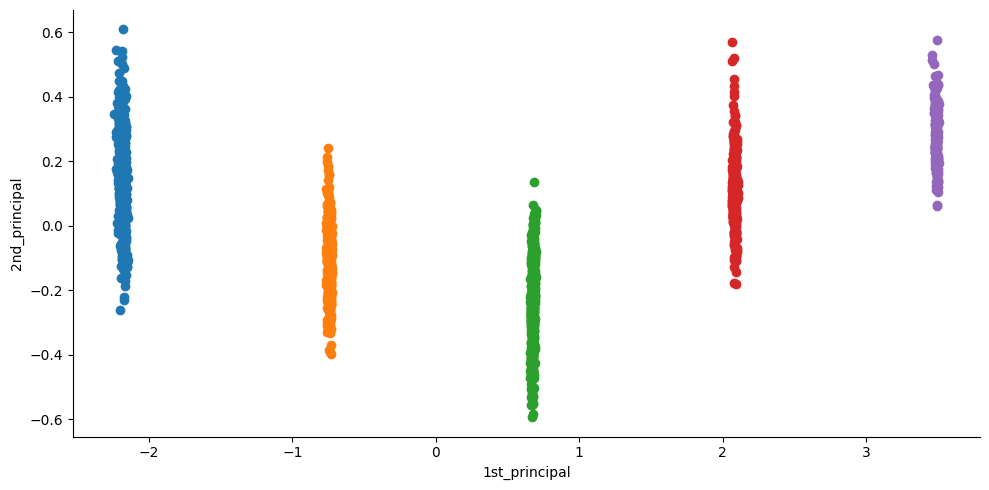

In [ ]:
# Visualization
g = sns.FacetGrid(pca_df, hue="label",height=5 ,aspect= 2)
g.map(plt.scatter, '1st_principal', '2nd_principal')
plt.show()

#### **TSNE Visualisation**

In [ ]:
from sklearn.manifold import TSNE

# t-SNE dimensionality reduction
model = TSNE(n_components=2, random_state=0, perplexity=50)
tsne_data = model.fit_transform(scaled_df)

# Create DataFrame for plotting
tsne_df = pd.DataFrame(data=np.vstack((tsne_data.T, scaled_df['Y_Predicted'])).T, columns=("Dim_1", "Dim_2", "label"))



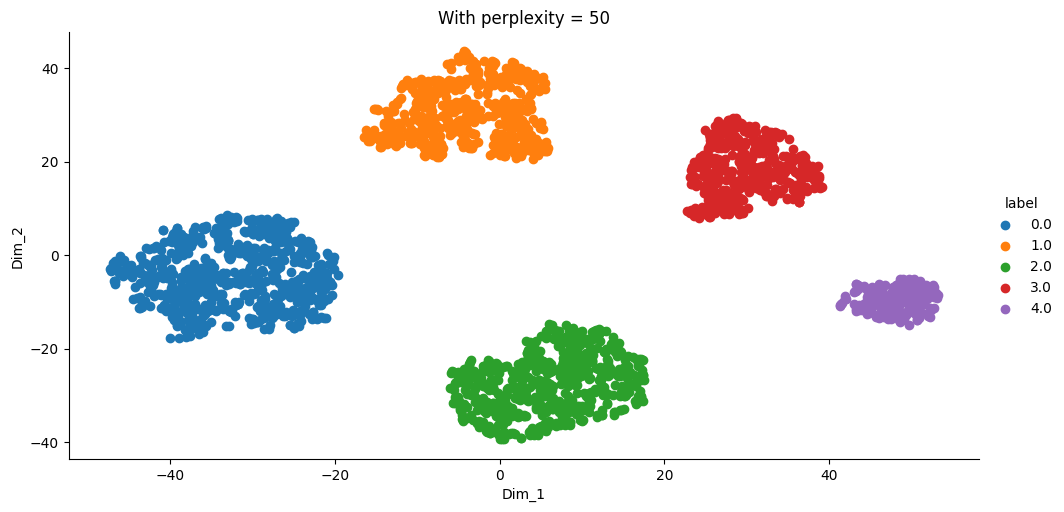

In [ ]:
# Plot using Seaborn
sns.FacetGrid(tsne_df, hue="label", height=5 ,aspect= 2).map(plt.scatter, 'Dim_1', 'Dim_2').add_legend()
plt.title('With perplexity = 50')
plt.show()


## Comparision with K-means ++
---

| Algorithm | K-means++ | Agglomerative |
|---|---|---|
| Time complexity | ---- | ---- |
| Space complexity | -- | -- |
| Evalution score | -- | -- |

## Limitations of Agglomerative Complexity
---



1. With large datasets, Agglomerative Clustering does not work well

  - Space Complexity = $O(n^2)$ : Proximity Matrix

  - Time Complexity = $O(n^3)$

<img src="https://drive.google.com/uc?export=view&id=1ccxO0Q1fcjWTRA9HmWRMTT-Gm8nkBr8O">

2. Unlike K-means where we try to minimize **within-cluster distance**, there is  **no mathematical objective** that is being minimized in Agglomerative clustering

***
***

<!-- **Instructor Notes**

There is a post read following this lecture which contains two topics:
  1. K-Medoids
  2. Pros and Cons of using different methods to update Proximity Matrix.

Encourage students to give it a read.

https://colab.research.google.com/drive/14eo3Q-SwHJg767_DE4RP0j6f5vdZHEq6?usp=sharing -->